# now we will look at results for single value predictors

In [1]:
import pandas as pd

path = "/data1/lesliec/sarthak/data/joint_playground/e2g/ENCODE-rE2G_extended_CrossValidated_K562_EPCrisprBenchmark_ensemble_data_GRCh38.predictions.tsv.gz"
df = pd.read_csv(path, sep='\t')

import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)

name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()
name_to_ensg = {name: ensg for name, ensg in name_to_ensg.items() if ensg in tss_dict}
gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated']).reset_index(drop=True)
gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214,ENSG00000116198
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214,ENSG00000130764
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848,ENSG00000130764
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214,ENSG00000235169
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848,ENSG00000235169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408,ENSG00000196976
10276,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569,ENSG00000102178
10277,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408,ENSG00000102178
10278,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408,ENSG00000130826


In [3]:
df['master'] = df['chr'] + ":" + df['start'].astype(str) + "-" + df['end'].astype(str) + "_" + df['TargetGene']
gs_df['master'] = gs_df['chrom'] + ":" + gs_df['chromStart'].astype(str) + "-" + gs_df['chromEnd'].astype(str) + "_" + gs_df['measuredGeneSymbol']
#now subset df to gs_df values
# subset_df = df[df['master'].isin(gs_df['master'])].reset_index(drop=True)
subset_df = gs_df[['master']].merge(df, on='master', how='inner')
subset_df

,master,chr,start,end,name,class,TargetGene,TargetGeneEnsemblID,TargetGeneTSS,CellType,FullModel.Score,FullModel_minus_EP300.Score,DistanceToTSS
0,chr1:3774714-3775214_CEP104,chr1,3774714,3775214,chr1:3774714-3775214,NaN,CEP104,NaN,3857213,K562,0.096023,0.119478,81923.0
1,chr1:3774714-3775214_LRRC47,chr1,3774714,3775214,chr1:3774714-3775214,NaN,LRRC47,NaN,3796503,K562,0.400644,0.418431,21194.0
2,chr1:3803570-3805848_LRRC47,chr1,3803570,3805848,chr1:3803570-3805848,NaN,LRRC47,NaN,3796503,K562,0.246991,0.231678,7776.0
3,chr1:3774714-3775214_SMIM1,chr1,3774714,3775214,chr1:3774714-3775214,NaN,SMIM1,NaN,3772761,K562,0.991864,0.990204,2524.0
4,chr1:3803570-3805848_SMIM1,chr1,3803570,3805848,chr1:3803570-3805848,NaN,SMIM1,NaN,3772788,K562,0.094680,0.076260,31494.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,chrX:155434755-155435408_LAGE3,chrX,155434755,155435408,chrX:155434755-155435408,NaN,LAGE3,NaN,154479256,K562,0.002902,0.003605,955564.0
10276,chrX:154527069-154527569_UBL4A,chrX,154527069,154527569,chrX:154527069-154527569,NaN,UBL4A,NaN,154486669,K562,0.050941,0.118676,40761.5
10277,chrX:155434755-155435408_UBL4A,chrX,155434755,155435408,chrX:155434755-155435408,NaN,UBL4A,NaN,154486669,K562,0.006867,0.008849,948151.0
10278,chrX:155434755-155435408_DKC1,chrX,155434755,155435408,chrX:155434755-155435408,NaN,DKC1,NaN,154762742,K562,0.000567,0.000665,672080.0


In [2]:
import numpy as np
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_tss.npy')
outputs2 = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_tss_500bp.npy')
outputs3 = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_tss_simpledecoder.npy')

# in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_tss_in_context.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_cage_tss_centered_in_context.npy')

print(outputs.shape, outputs2.shape, outputs3.shape, in_context.shape)
# print(np.allclose(in_context, in_context2))

(10280, 2) (10280, 2) (10280, 2) (10280,)


In [4]:
#now it's easy, just do log difference and they're already log space so literallyy just subtract

from tqdm import tqdm
def make_score_vector(outputs, in_context, mask_len_maintss=100, mask_len_alttss=100, pseudo_count=1e-2,
                      assay_type='CAGE', model_type='enformer', gtf=None, gene_to_idxs=None):
    # outputs.shape[1] == 4  → model has 2 output channels (before+, before-, after+, after-)
    # outputs.shape[1] == 8  → model has 4 output channels / 'both' (CAGE+,CAGE-,RNA+,RNA- × before/after)

    if assay_type == 'TSS':
        return outputs[:,1] - outputs[:,0] #it's predicting log already, so perfectly fine!

    score_vector = np.zeros(len(gs_df))
    if model_type == 'enformer':
        size = 896
        assert outputs.shape[2] == size, f"Expected outputs to have size {size} in last dimension, got {outputs.shape[2]}"
        bin_size = 128
    elif model_type == 'borzoi':
        size = 6144
        assert outputs.shape[2] == size, f"Expected outputs to have size {size} in last dimension, got {outputs.shape[2]}"
        bin_size = 32

    n_channels = outputs.shape[1]  # 4 or 8

    for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
        if not in_context[i]:
            score_vector[i] = 0
            continue

        ensgid = row['ensg_id']
        temp_tss = tss_dict[ensgid]['tss']
        strand = tss_dict[ensgid]['strand']

        gene_location = size // 2
        tempout = outputs[i]  # (n_channels, size)

        # --- Determine og_idx / alt_idx ---
        if model_type == 'enformer':
            og_idx = 0
            alt_idx = 1
        elif n_channels == 8:
            # 4-channel 'both' model: CAGE+/CAGE-/RNA+/RNA- × before/after
            # before: 0,1,2,3  |  after: 4,5,6,7
            if assay_type == 'RNA':
                og_idx  = 2 if strand == '+' else 3
                alt_idx = 6 if strand == '+' else 7
            else:  # CAGE
                og_idx  = 0 if strand == '+' else 1
                alt_idx = 4 if strand == '+' else 5
        else:
            # 2-channel model: before+/before-/after+/after-  (n_channels == 4)
            og_idx  = 0 if strand == '+' else 1
            alt_idx = 2 if strand == '+' else 3

        # --- Build mask ---
        if assay_type == 'RNA':
            # Sum over exon bins rather than TSS window
            if gtf is None or gene_to_idxs is None:
                raise ValueError("gtf and gene_to_idxs are required for assay_type='RNA'")

            gene_rows = gtf.iloc[gene_to_idxs[ensgid]]
            exons = gene_rows[gene_rows['feature'] == 'exon']

            mask = np.zeros(size)
            for _, exon in exons.iterrows():
                # GTF coords are 1-based closed; convert to bin indices relative to TSS center
                exon_start_bin = ((exon['start'] - 1 - temp_tss) // bin_size) + gene_location
                exon_end_bin   = ((exon['end']  - temp_tss) // bin_size) + gene_location
                exon_start_bin = max(0, exon_start_bin)
                exon_end_bin   = min(size, exon_end_bin)
                if exon_start_bin < exon_end_bin:
                    mask[exon_start_bin:exon_end_bin] = 1
        else:
            # CAGE: mask around main TSS and alt TSSs
            mask = np.zeros(size)
            startmask = max(0, gene_location - mask_len_maintss)
            endmask   = min(size, gene_location + mask_len_maintss + 1)
            mask[startmask:endmask] = 1

            alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
            if mask_len_alttss > 0:
                for alt in alt_tss:
                    alt_location = int(size // 2 + alt // bin_size)
                    if alt_location < 0 or alt_location >= size:
                        continue
                    alt_startmask = max(0, alt_location - mask_len_alttss)
                    alt_endmask   = min(size, alt_location + mask_len_alttss + 1)
                    mask[alt_startmask:alt_endmask] = 1

        original_sum = (tempout[og_idx] * mask).sum()
        altered_sum  = (tempout[alt_idx] * mask).sum()

        score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

    return score_vector

score_vector = make_score_vector(outputs, in_context, assay_type='TSS', model_type='enformer')
score_vector2 = make_score_vector(outputs2, in_context, assay_type='TSS', model_type='enformer')
score_vector3 = make_score_vector(outputs3, in_context, assay_type='TSS', model_type='enformer')
score_vector

array([-7.64846802e-04, -1.34468079e-04, -5.09703636e-01, ...,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [5]:
#now let's score them!
distance_vector = subset_df['DistanceToTSS'].values

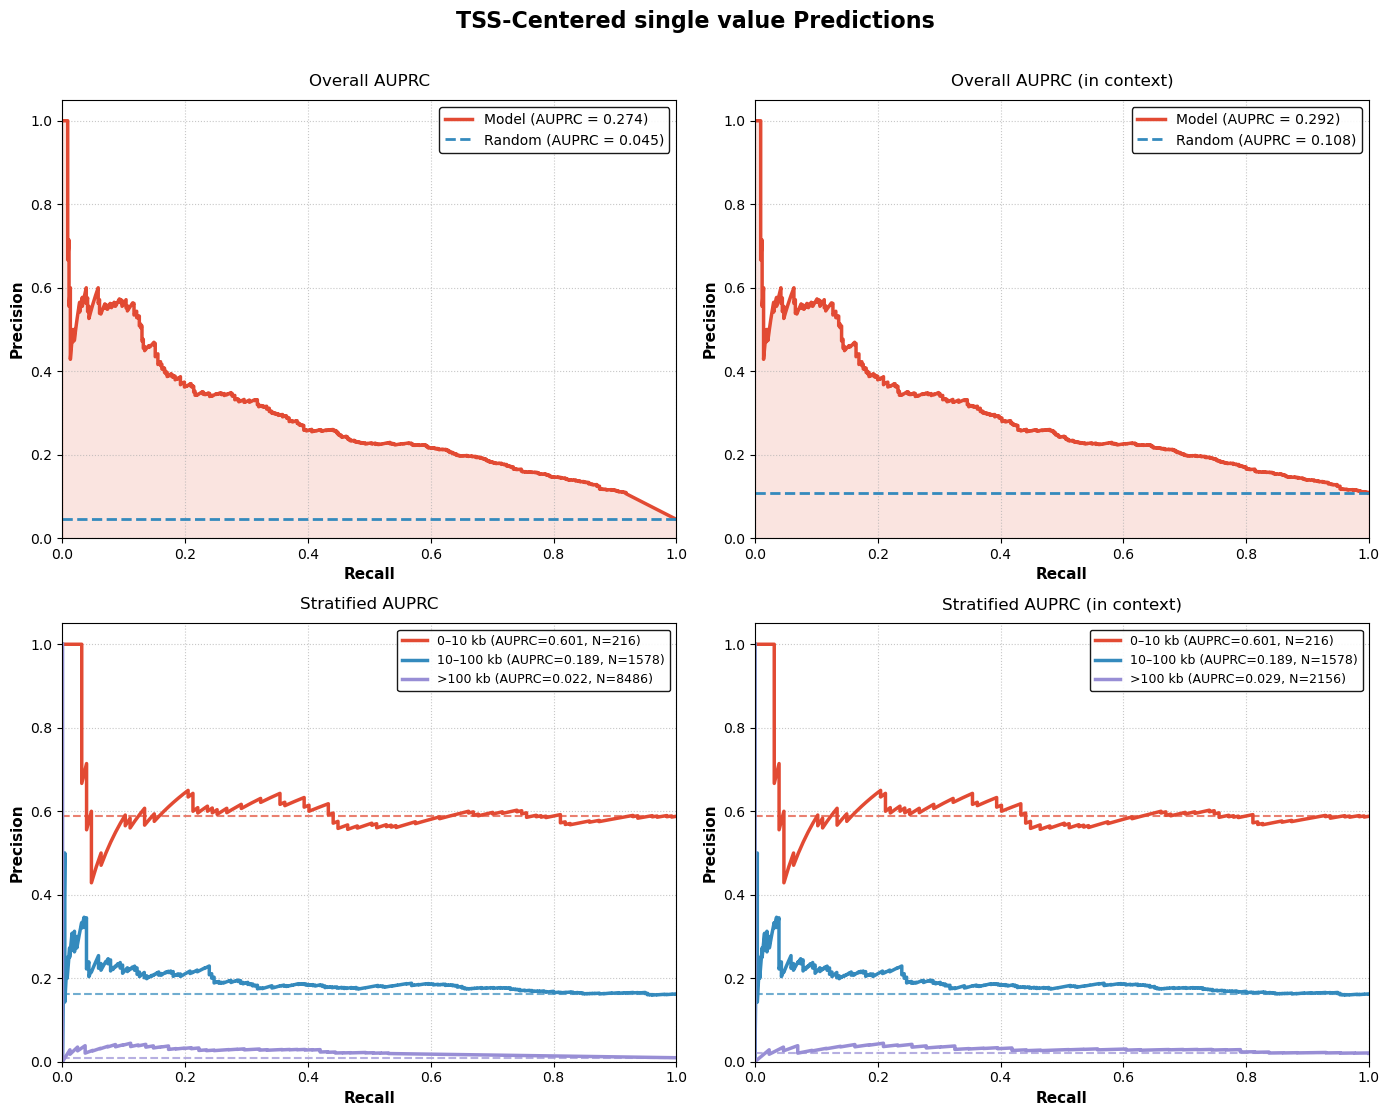

In [6]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title=None):
    """
    2x2 subplot summary of AUPRC performance.
    
    Parameters
    ----------
    score_vector  : np.ndarray (N,)  – pre-computed scores (e.g. log2 fold-change)
    in_context    : np.ndarray (N,)  – boolean mask of enhancers within the input crop
    gs_df         : pd.DataFrame     – must contain 'Regulated' column
    distance_vector : np.ndarray (N,) – enhancer-to-TSS distances (absolute values)
    title         : str, optional    – overall figure suptitle
    """
    y_score_all = np.abs(score_vector)
    y_true_all  = gs_df['Regulated'].astype(int).values
    dist_all    = np.abs(distance_vector)

    y_score_ctx = y_score_all[in_context]
    y_true_ctx  = y_true_all[in_context]
    dist_ctx    = dist_all[in_context]

    distance_bins = [
        ("0–10 kb",    lambda d: d <= 10_000),
        ("10–100 kb",  lambda d: (d > 10_000) & (d <= 100_000)),
        (">100 kb",    lambda d: d > 100_000),
    ]
    bin_colors = ['#E24A33', '#348ABD', '#988ED5']

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    # ── helper: single overall PR curve ──────────────────────────────────────
    def _plot_overall(ax, y_true, y_score, subtitle):
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        aupr     = auc(rec, prec)
        baseline = y_true.mean()

        ax.plot(rec, prec, color='#E24A33', lw=2.5,
                label=f'Model (AUPRC = {aupr:.3f})')
        ax.fill_between(rec, prec, alpha=0.15, color='#E24A33')
        ax.axhline(baseline, color='#348ABD', lw=2, linestyle='--',
                   label=f'Random (AUPRC = {baseline:.3f})')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='black')

    # ── helper: distance-stratified PR curves ────────────────────────────────
    def _plot_stratified(ax, y_true, y_score, distances, subtitle):
        for (label, mask_fn), color in zip(distance_bins, bin_colors):
            mask = mask_fn(distances)
            if mask.sum() == 0:
                continue
            yt, ys = y_true[mask], y_score[mask]
            prec, rec, _ = precision_recall_curve(yt, ys)
            aupr     = auc(rec, prec)
            baseline = yt.mean()
            ax.plot(rec, prec, color=color, lw=2.5,
                    label=f'{label} (AUPRC={aupr:.3f}, N={mask.sum()})')
            ax.axhline(baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='black')

    # ── fill the 4 panels ────────────────────────────────────────────────────
    _plot_overall   (axes[0, 0], y_true_all, y_score_all, 'Overall AUPRC')
    _plot_overall   (axes[0, 1], y_true_ctx, y_score_ctx, 'Overall AUPRC (in context)')
    _plot_stratified(axes[1, 0], y_true_all, y_score_all, dist_all, 'Stratified AUPRC')
    _plot_stratified(axes[1, 1], y_true_ctx, y_score_ctx, dist_ctx, 'Stratified AUPRC (in context)')

    plt.tight_layout()
    plt.show()
plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title='TSS-Centered single value Predictions')

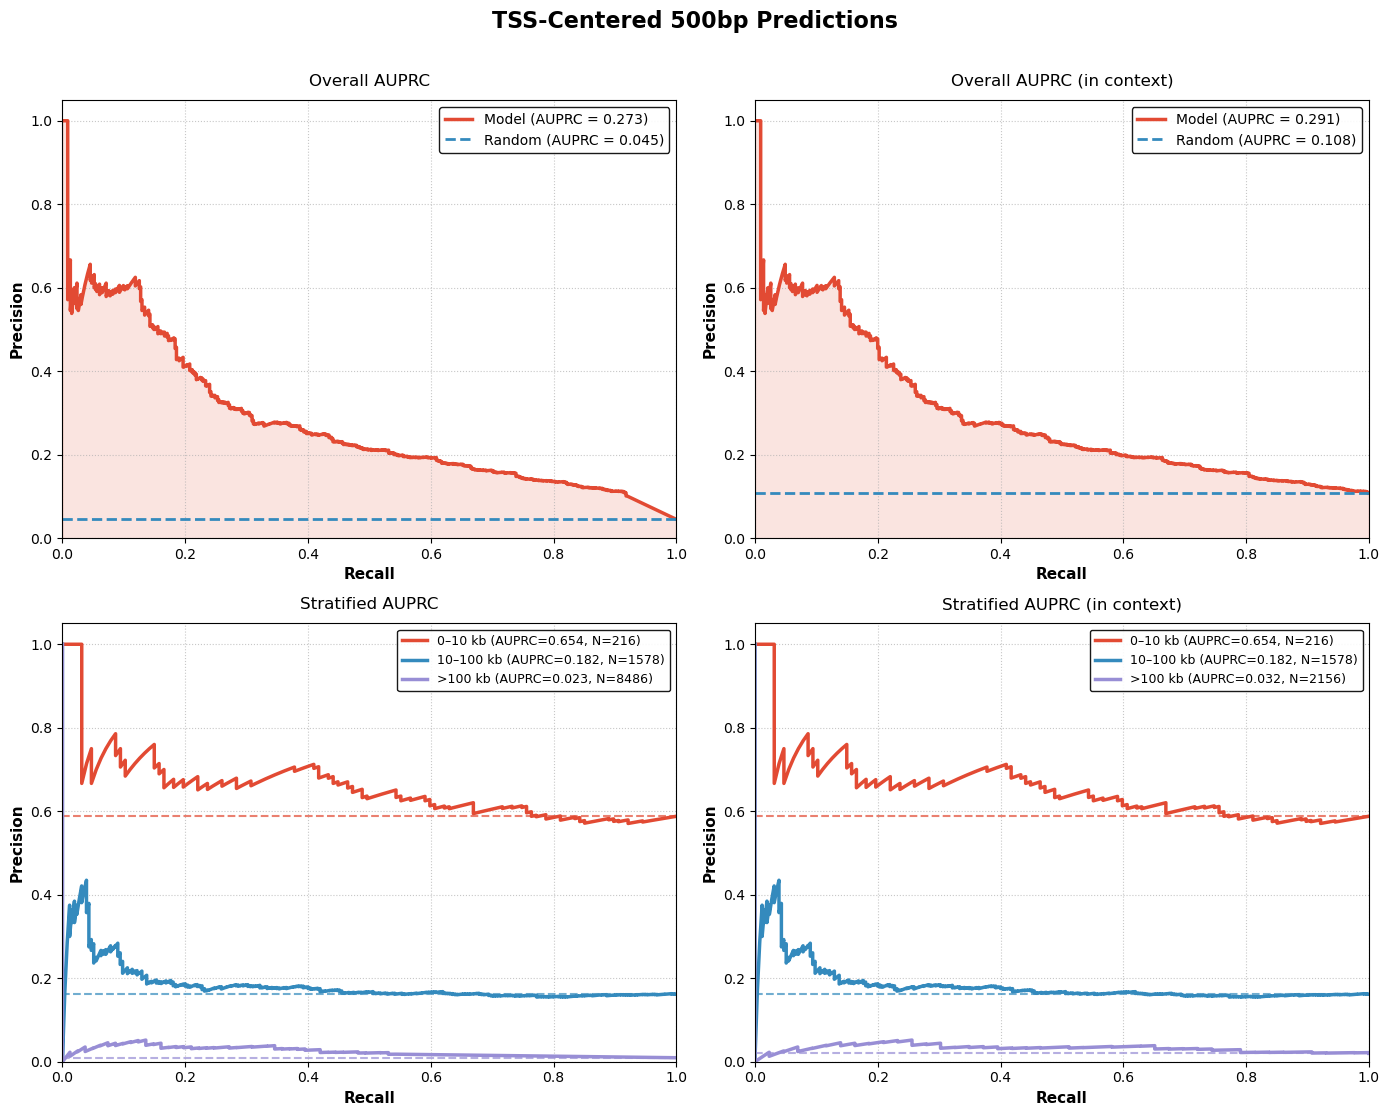

In [7]:
plot_auprc_2x2(score_vector2, in_context, gs_df, distance_vector, title='TSS-Centered 500bp Predictions')

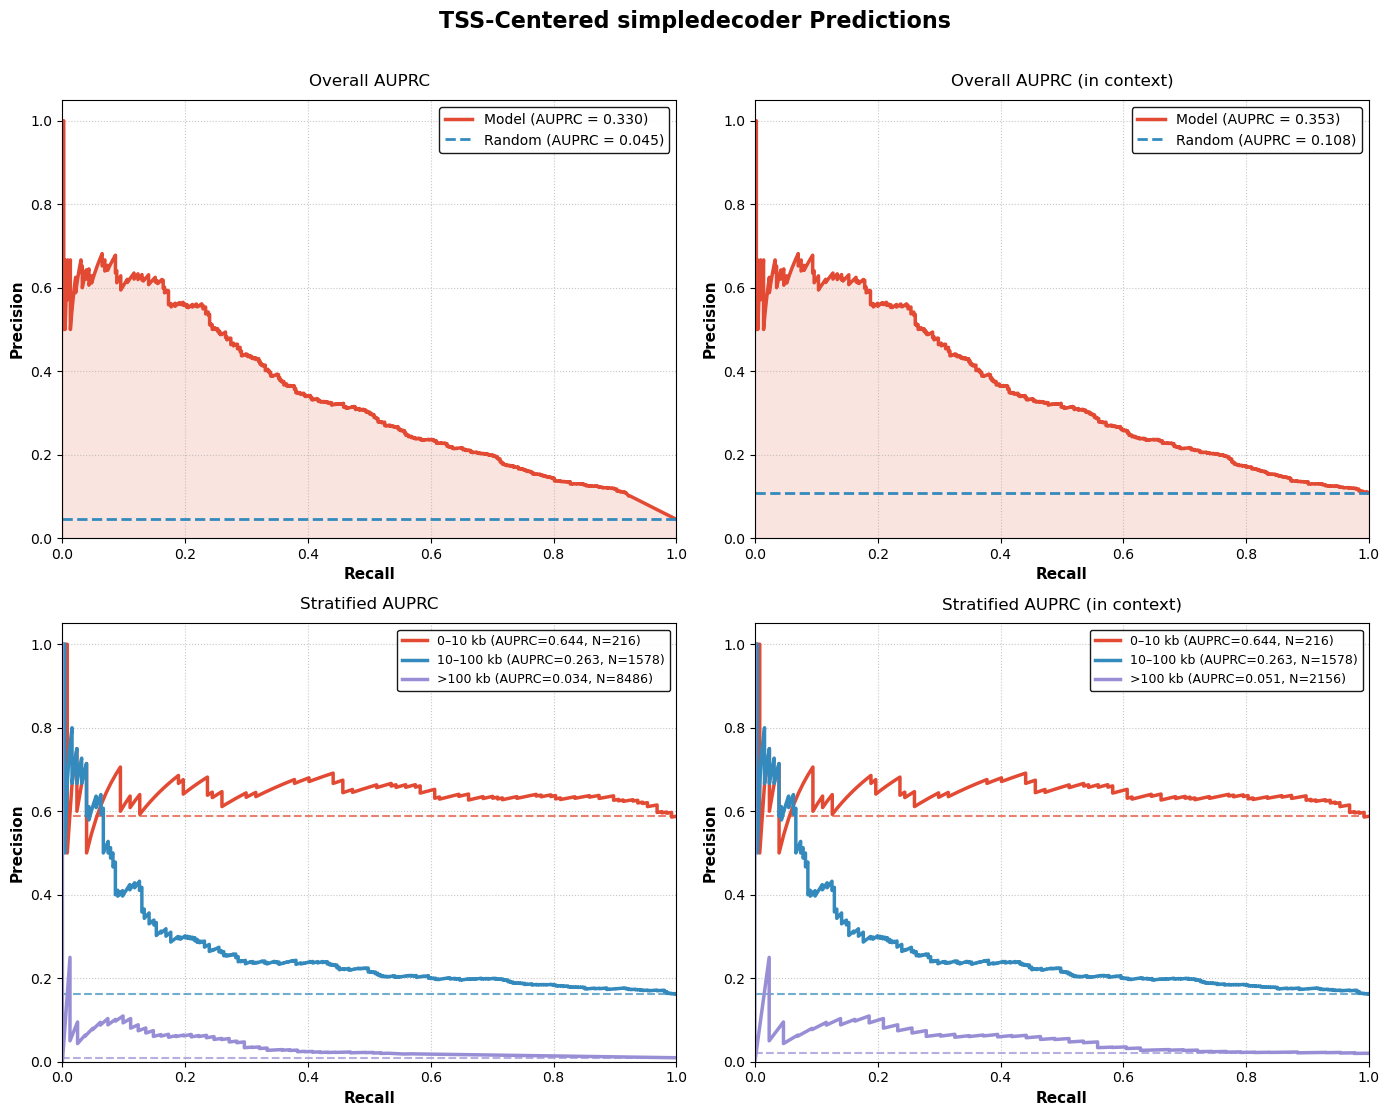

In [9]:
plot_auprc_2x2(score_vector3, in_context, gs_df, distance_vector, title='TSS-Centered simpledecoder Predictions')

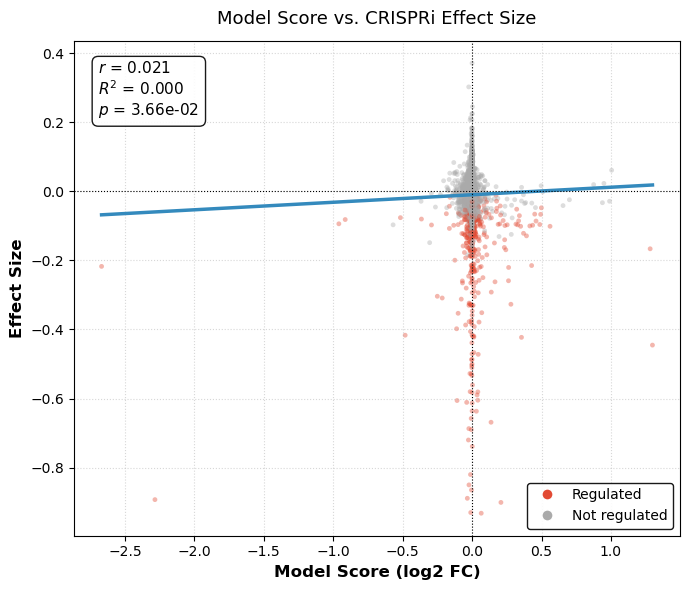

In [11]:
#let's also plot it compared to actual effect size
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# Prepare data
df_plot = gs_df.copy()
df_plot['Model_Score'] = -score_vector
# df_plot = df_plot[df_plot['Regulated'] == True] # Only consider regulated pairs for the regression

# Fit regression
X = df_plot['Model_Score'].values.reshape(-1, 1)
y = df_plot['EffectSize'].values

#get only ones in cocntext

reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)

# Pearson r for annotation
r, pval = stats.pearsonr(df_plot['Model_Score'].values, y)
pval_str = f'{pval:.2e}' if pval > 1e-300 else '< 1e-300'

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Scatter: color by Regulated status
colors = df_plot['Regulated'].map({True: '#E24A33', False: '#aaaaaa'})
ax.scatter(df_plot['Model_Score'], y,
           c=colors, alpha=0.4, s=12, linewidths=0, rasterized=True)

# Regression line
x_range = np.linspace(df_plot['Model_Score'].min(), df_plot['Model_Score'].max(), 200)
ax.plot(x_range, reg.predict(x_range.reshape(-1, 1)),
        color='#348ABD', lw=2.5, label=f'Linear fit')

# Reference lines
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.axvline(0, color='black', lw=0.8, linestyle=':')

# Annotation box
textstr = f'$r$ = {r:.3f}\n$R^2$ = {r2:.3f}\n$p$ = {pval_str}'
ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=0.9))

# Legend for color coding
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24A33', markersize=8, label='Regulated'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#aaaaaa', markersize=8, label='Not regulated'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='black')

ax.set_xlabel('Model Score (log2 FC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effect Size', fontsize=12, fontweight='bold')
ax.set_title('Model Score vs. CRISPRi Effect Size', fontsize=13, pad=12)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

